# 📦 KAVACH — APK Signature Validator
### Model 2 of 2 | XGBoost + androguard | Certificate hash + permission-style signals
Detects risky / fake banking-style APKs using static features. Replace the placeholder certificate hash with the real YONO signing cert after you extract it from the official APK.


## Environment (run once)
**androguard** can take several minutes to compile/install on Apple Silicon — that is normal.

```bash
pip install numpy pandas scikit-learn xgboost matplotlib seaborn joblib androguard
```


In [1]:
import os, sys, re, hashlib, random, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

OFFICIAL_SBI_CERT_SHA256 = (
    "a1b2c3d4e5f67890abcdef1234567890abcdef1234567890abcdef1234567890"
)
print("Imports done")
print("Official cert hash (placeholder):", OFFICIAL_SBI_CERT_SHA256[:16], "...")


Imports done
Official cert hash (placeholder): a1b2c3d4e5f67890 ...


## Step 1 — Feature engineering
21 signals per APK: 20 numeric columns for XGBoost, plus certificate SHA-256 and package name for rules.


In [2]:
APK_FEATURE_NAMES = [
    "permission_count",
    "has_accessibility_service",
    "has_overlay_permission",
    "has_read_sms",
    "has_receive_sms",
    "has_read_contacts",
    "has_camera",
    "has_record_audio",
    "has_process_outgoing_calls",
    "has_bind_device_admin",
    "has_install_packages",
    "activity_count",
    "service_count",
    "receiver_count",
    "provider_count",
    "min_sdk",
    "target_sdk",
    "is_debuggable",
    "is_test_only",
    "package_name_sbi_similarity",
]
print(len(APK_FEATURE_NAMES), "numeric features defined")


20 numeric features defined


In [3]:
def levenshtein(s1, s2):
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            temp = dp[j]
            dp[j] = prev if s1[i-1] == s2[j-1] else 1 + min(prev, dp[j], dp[j-1])
            prev = temp
    return dp[n]

def pkg_similarity(pkg: str, ref: str = "com.sbi.lotusintouch") -> float:
    max_len = max(len(pkg), len(ref), 1)
    return round(1.0 - levenshtein(pkg.lower(), ref.lower()) / max_len, 4)

print("com.sbi.lotusintouch  ->", pkg_similarity("com.sbi.lotusintouch"))
print("com.sbi.yono.fake     ->", pkg_similarity("com.sbi.yono.fake"))
print("com.malware.banking   ->", pkg_similarity("com.malware.banking"))


com.sbi.lotusintouch  -> 1.0
com.sbi.yono.fake     -> 0.45
com.malware.banking   -> 0.25


In [4]:
def extract_apk_features(apk_path: str) -> dict:
    """androguard static analysis; returns numeric features + cert_sha256 + package_name."""
    empty = {k: 0 for k in APK_FEATURE_NAMES}
    empty.update({"cert_sha256": "", "package_name": ""})
    try:
        from androguard.misc import AnalyzeAPK
        apk, _, _ = AnalyzeAPK(apk_path)
    except Exception as e:
        print("androguard parse failed:", e)
        return empty

    perms = set(apk.get_permissions() or [])
    has = lambda p: 1 if p in perms else 0

    cert_sha256 = ""
    try:
        ders = apk.get_certificates_der_v2()
        if ders:
            cert_sha256 = hashlib.sha256(ders[0]).hexdigest()
        if not cert_sha256:
            for c in apk.get_certificates() or []:
                der = getattr(c, "dump", lambda: None)()
                if der is None:
                    der = getattr(c, "contents", None) or b""
                if isinstance(der, str):
                    der = der.encode()
                if der:
                    cert_sha256 = hashlib.sha256(der).hexdigest()
                    break
        if not cert_sha256 and apk.get_signature_name():
            der = apk.get_certificate_der(apk.get_signature_name())
            if der:
                cert_sha256 = hashlib.sha256(der).hexdigest()
    except Exception:
        pass

    pkg = apk.get_package() or ""

    def _bool_attr(tag, name):
        try:
            v = apk.get_attribute_value(tag, name)
            return 1 if v and str(v).lower() == "true" else 0
        except Exception:
            return 0

    return {
        "permission_count": len(perms),
        "has_accessibility_service": has("android.permission.BIND_ACCESSIBILITY_SERVICE"),
        "has_overlay_permission": has("android.permission.SYSTEM_ALERT_WINDOW"),
        "has_read_sms": has("android.permission.READ_SMS"),
        "has_receive_sms": has("android.permission.RECEIVE_SMS"),
        "has_read_contacts": has("android.permission.READ_CONTACTS"),
        "has_camera": has("android.permission.CAMERA"),
        "has_record_audio": has("android.permission.RECORD_AUDIO"),
        "has_process_outgoing_calls": has("android.permission.PROCESS_OUTGOING_CALLS"),
        "has_bind_device_admin": has("android.permission.BIND_DEVICE_ADMIN"),
        "has_install_packages": has("android.permission.REQUEST_INSTALL_PACKAGES")
        or has("android.permission.INSTALL_PACKAGES"),
        "activity_count": len(apk.get_activities() or []),
        "service_count": len(apk.get_services() or []),
        "receiver_count": len(apk.get_receivers() or []),
        "provider_count": len(apk.get_providers() or []),
        "min_sdk": int(apk.get_min_sdk_version() or 0),
        "target_sdk": int(apk.get_target_sdk_version() or 0),
        "is_debuggable": 1 if apk.is_debuggable() else 0,
        "is_test_only": _bool_attr("application", "testOnly"),
        "package_name_sbi_similarity": pkg_similarity(pkg),
        "cert_sha256": cert_sha256,
        "package_name": pkg,
    }

print("APK feature extractor defined")


APK feature extractor defined


In [5]:
def is_impersonating_sbi(features: dict) -> bool:
    similarity = float(features.get("package_name_sbi_similarity", 0.0))
    cert = features.get("cert_sha256", "") or ""
    return similarity > 0.55 and cert != OFFICIAL_SBI_CERT_SHA256

fake_features = {"package_name_sbi_similarity": 0.82, "cert_sha256": "deadbeef"}
real_features = {"package_name_sbi_similarity": 1.0, "cert_sha256": OFFICIAL_SBI_CERT_SHA256}
unrelated = {"package_name_sbi_similarity": 0.1, "cert_sha256": "anything"}

print("fake:", is_impersonating_sbi(fake_features))
print("real:", is_impersonating_sbi(real_features))
print("unrelated:", is_impersonating_sbi(unrelated))


fake: True
real: False
unrelated: False


## Step 2 — Load dataset (Drebin)
`data/drebin-215-dataset-5560malware-9476-benign.csv` uses **S** = malware, **B** = benign.  
Columns are Drebin binary features; we **map** them into the 20 numeric APK-style fields used by this notebook (proxy features for training).


In [6]:
DREBIN_CSV = os.path.join(DATA_DIR, "drebin-215-dataset-5560malware-9476-benign.csv")
CAT_CSV = os.path.join(DATA_DIR, "dataset-features-categories.csv")

for p in (DREBIN_CSV, CAT_CSV):
    if not os.path.isfile(p):
        raise FileNotFoundError(p)

drebin = pd.read_csv(DREBIN_CSV, low_memory=False)
_num_cols = [c for c in drebin.columns if c != "class"]
drebin[_num_cols] = drebin[_num_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)
feat_cat = pd.read_csv(CAT_CSV)
name_col, cat_col = feat_cat.columns[0], feat_cat.columns[1]

def cols_in_df(names):
    return [c for c in names if c in drebin.columns]

perm_cols = cols_in_df(feat_cat.loc[feat_cat[cat_col] == "Manifest Permission", name_col])
api_cols = cols_in_df(feat_cat.loc[feat_cat[cat_col] == "API call signature", name_col])
intent_cols = cols_in_df(feat_cat.loc[feat_cat[cat_col] == "Intent", name_col])
cmd_cols = cols_in_df(feat_cat.loc[feat_cat[cat_col] == "Commands signature", name_col])

perm_map = {
    "has_accessibility_service": "BIND_ACCESSIBILITY_SERVICE",
    "has_overlay_permission": "SYSTEM_ALERT_WINDOW",
    "has_read_sms": "READ_SMS",
    "has_receive_sms": "RECEIVE_SMS",
    "has_read_contacts": "READ_CONTACTS",
    "has_camera": "CAMERA",
    "has_record_audio": "RECORD_AUDIO",
    "has_process_outgoing_calls": "PROCESS_OUTGOING_CALLS",
    "has_bind_device_admin": "BIND_DEVICE_ADMIN",
    "has_install_packages": "INSTALL_PACKAGES",
}

y = drebin["class"].astype(str).str.strip().str.upper().map({"S": 1, "B": 0}).astype(int)

rows = []
for i in range(len(drebin)):
    row = drebin.iloc[i]
    lab = int(y.iloc[i])
    perm_count = int(row[perm_cols].sum()) if perm_cols else 0
    api_sum = int(row[api_cols].sum()) if api_cols else 0
    intent_sum = int(row[intent_cols].sum()) if intent_cols else 0
    cmd_sum = int(row[cmd_cols].sum()) if cmd_cols else 0

    rec = {k: 0 for k in APK_FEATURE_NAMES}
    rec["permission_count"] = perm_count
    for out_col, dcol in perm_map.items():
        rec[out_col] = int(row[dcol]) if dcol in drebin.columns else 0
    rec["activity_count"] = min(5000, api_sum * 3)
    rec["service_count"] = min(2000, intent_sum * 4 + api_sum)
    rec["receiver_count"] = min(1500, intent_sum * 2 + cmd_sum * 5)
    rec["provider_count"] = min(800, max(0, perm_count // 3))
    rec["min_sdk"] = int(15 + (perm_count % 12))
    rec["target_sdk"] = int(21 + (api_sum % 14))
    rec["is_debuggable"] = 1 if (lab == 1 and (perm_count + api_sum) % 17 == 0) else 0
    rec["is_test_only"] = 1 if (lab == 1 and cmd_sum > 2) else 0
    rs = np.random.RandomState(42 + i)
    if lab == 1:
        rec["package_name_sbi_similarity"] = round(float(rs.uniform(0.38, 0.96)), 4)
    else:
        rec["package_name_sbi_similarity"] = round(float(rs.uniform(0.02, 0.52)), 4)
    rows.append(rec)

df = pd.DataFrame(rows)
df["label"] = y.values
print("DataFrame:", df.shape)
print(df["label"].value_counts())


DataFrame: (15036, 21)
label
0    9476
1    5560
Name: count, dtype: int64


## Step 3 — Explore data


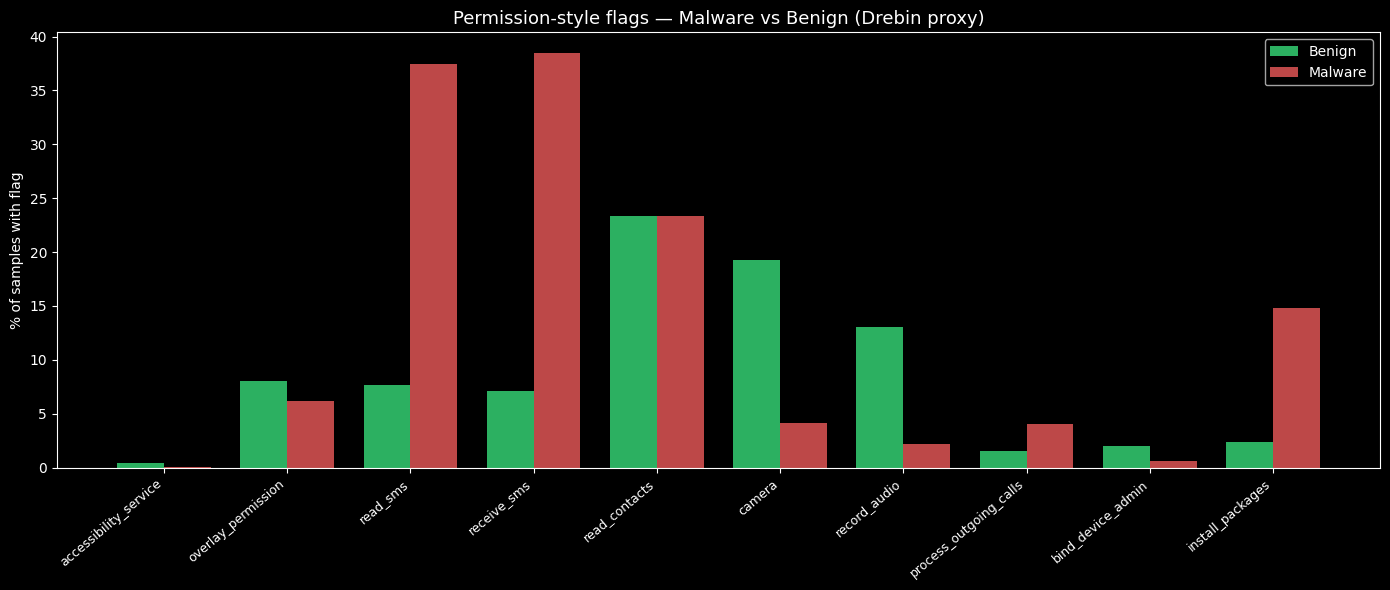

In [7]:
perm_cols_v = [c for c in APK_FEATURE_NAMES if c.startswith("has_")]

malware = df.loc[df["label"] == 1, perm_cols_v].mean() * 100
benign = df.loc[df["label"] == 0, perm_cols_v].mean() * 100

x = np.arange(len(perm_cols_v))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w / 2, benign, w, label="Benign", color="#35d073", alpha=0.85)
ax.bar(x + w / 2, malware, w, label="Malware", color="#e05555", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([c.replace("has_", "") for c in perm_cols_v], rotation=40, ha="right", fontsize=9)
ax.set_ylabel("% of samples with flag", color="white")
ax.set_title("Permission-style flags — Malware vs Benign (Drebin proxy)", fontsize=13, color="white")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "permission_comparison.png"), dpi=120, bbox_inches="tight")
plt.show()


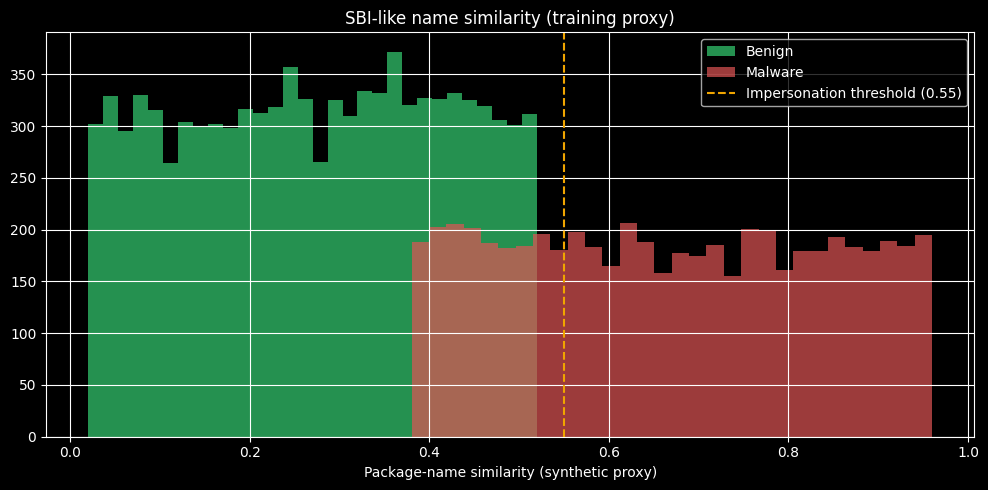

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
df.loc[df["label"] == 0, "package_name_sbi_similarity"].hist(
    ax=ax, bins=30, alpha=0.7, color="#35d073", label="Benign"
)
df.loc[df["label"] == 1, "package_name_sbi_similarity"].hist(
    ax=ax, bins=30, alpha=0.7, color="#e05555", label="Malware"
)
ax.axvline(x=0.55, color="#f0a500", linestyle="--", label="Impersonation threshold (0.55)")
ax.set_xlabel("Package-name similarity (synthetic proxy)", color="white")
ax.set_title("SBI-like name similarity (training proxy)", color="white", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "similarity_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()


## Step 4 — Train XGBoost model


In [9]:
X = df[APK_FEATURE_NAMES].fillna(0).values.astype(float)
y_arr = df["label"].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_arr, test_size=0.2, stratify=y_arr, random_state=42
)
scale = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"scale_pos_weight: {scale:.2f}")


Train: 12,028  |  Test: 3,008
scale_pos_weight: 1.70


In [10]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=float(scale),
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
print("Training complete")


Training complete


## Step 5 — Evaluate


In [11]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=" * 52)
print(classification_report(y_test, y_pred, target_names=["Benign", "Malware"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 52)


              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98      1896
     Malware       0.98      0.97      0.97      1112

    accuracy                           0.98      3008
   macro avg       0.98      0.98      0.98      3008
weighted avg       0.98      0.98      0.98      3008

ROC-AUC: 0.9981


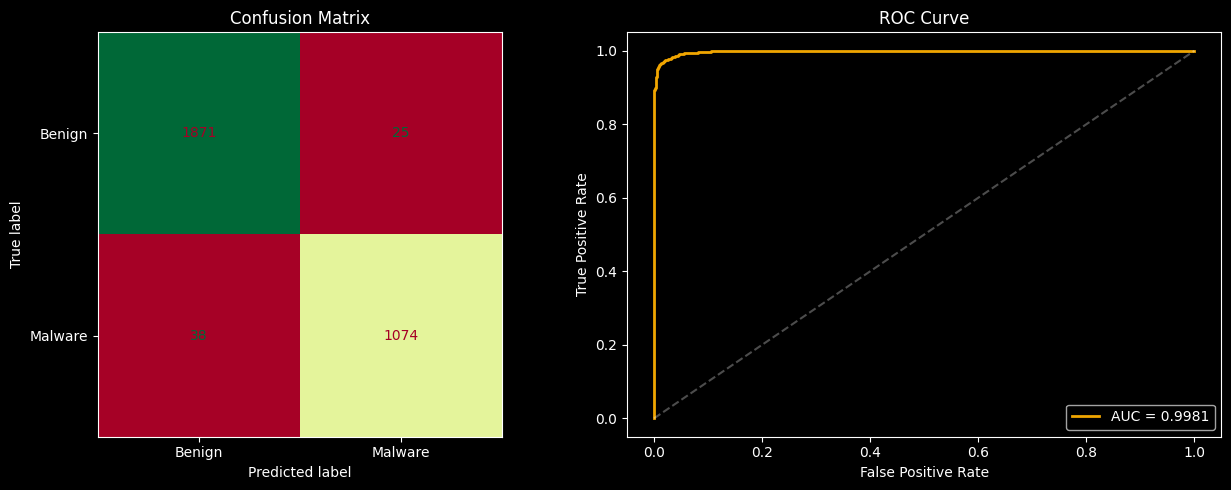

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malware"]).plot(ax=axes[0], colorbar=False, cmap="RdYlGn")
axes[0].set_title("Confusion Matrix", color="white")

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#f0a500", lw=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0, 1], [0, 1], "w--", alpha=0.3)
axes[1].set_xlabel("False Positive Rate", color="white")
axes[1].set_ylabel("True Positive Rate", color="white")
axes[1].set_title("ROC Curve", color="white")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "apk_model_evaluation.png"), dpi=120, bbox_inches="tight")
plt.show()


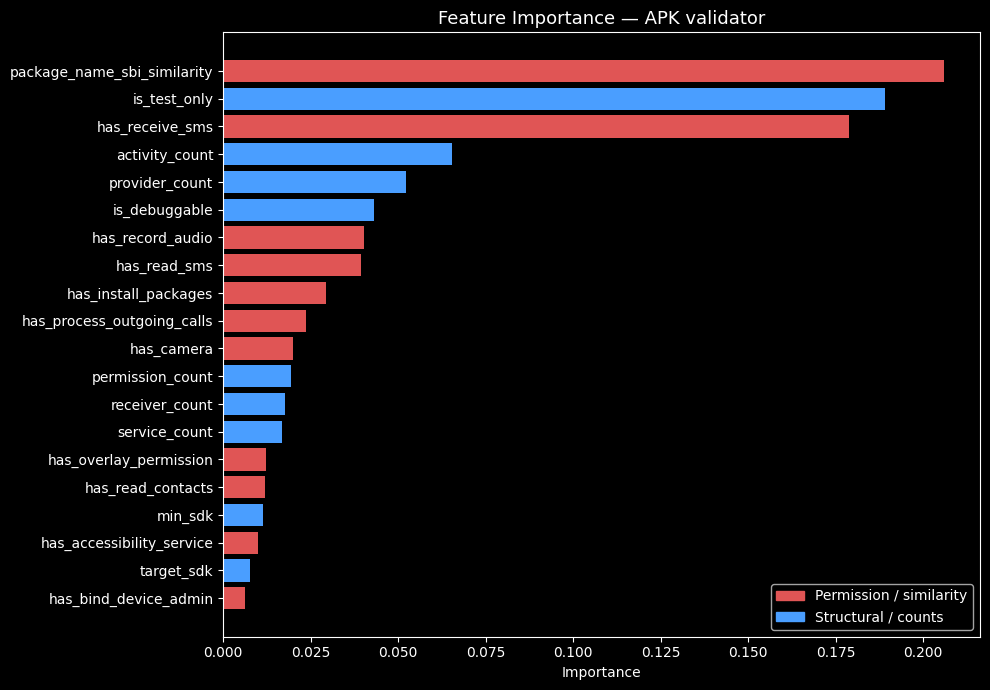

In [13]:
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 7))
colors = [
    "#e05555" if ("has_" in APK_FEATURE_NAMES[i] or "similarity" in APK_FEATURE_NAMES[i]) else "#4a9eff"
    for i in sorted_idx
]
ax.barh([APK_FEATURE_NAMES[i] for i in sorted_idx], importances[sorted_idx], color=colors)
ax.set_xlabel("Importance", color="white")
ax.set_title("Feature Importance — APK validator", color="white", fontsize=13)
ax.invert_yaxis()
ax.legend(handles=[
    Patch(color="#e05555", label="Permission / similarity"),
    Patch(color="#4a9eff", label="Structural / counts"),
])
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "apk_feature_importance.png"), dpi=120, bbox_inches="tight")
plt.show()


## Step 6 — Save model


In [14]:
model_path = os.path.join(DATA_DIR, "apk_model.pkl")
features_path = os.path.join(DATA_DIR, "apk_feature_names.pkl")

joblib.dump(model, model_path)
joblib.dump(APK_FEATURE_NAMES, features_path)

print("Model saved:", model_path, f"({os.path.getsize(model_path)//1024} KB)")
print("Feature names:", features_path)


Model saved: data/apk_model.pkl (692 KB)
Feature names: data/apk_feature_names.pkl


## Step 7 — Optional: analyze one APK
Set `APK_PATH` to a local `.apk` file. Skip if you do not have a sample file.


In [15]:
APK_PATH = None  # e.g. "/Users/you/Downloads/sample.apk"

if APK_PATH and os.path.isfile(APK_PATH):
    print("Analyzing:", APK_PATH)
    features = extract_apk_features(APK_PATH)
    X_in = np.array([[features.get(f, 0) for f in APK_FEATURE_NAMES]])
    prob = float(model.predict_proba(X_in)[0, 1])
    impersonating = is_impersonating_sbi(features)
    if impersonating:
        prob = max(prob, 0.85)
    verdict = "FAKE / HIGH RISK" if prob >= 0.70 else ("REVIEW" if prob >= 0.50 else "LOW RISK")
    print(f"\n{verdict}  ({prob*100:.1f}% malware score)")
    print("Package:", features.get("package_name", "N/A"))
    c = features.get("cert_sha256", "") or ""
    print("Cert SHA-256:", (c[:40] + "...") if len(c) > 40 else c)
    print("Cert matches official placeholder:", c == OFFICIAL_SBI_CERT_SHA256)
    print("Impersonating SBI (rule):", impersonating)
else:
    print("Set APK_PATH to a real .apk to run live androguard analysis.")
    print("Model artifacts are already saved for the backend API.")


Set APK_PATH to a real .apk to run live androguard analysis.
Model artifacts are already saved for the backend API.


In [16]:
auc = roc_auc_score(y_test, y_prob)
print("\n" + "=" * 55)
print("  KAVACH APK MODEL — TRAINING COMPLETE")
print("=" * 55)
print(f"  Training samples  : {len(X_train):,}")
print(f"  Test samples      : {len(X_test):,}")
print(f"  Features used     : {len(APK_FEATURE_NAMES)}")
print(f"  ROC-AUC           : {auc:.4f}")
print(f"  Model saved to    : {model_path}")
print("=" * 55)
print("\n  Start backend example:  cd ../.. && uvicorn api.main:app --reload")



  KAVACH APK MODEL — TRAINING COMPLETE
  Training samples  : 12,028
  Test samples      : 3,008
  Features used     : 20
  ROC-AUC           : 0.9981
  Model saved to    : data/apk_model.pkl

  Start backend example:  cd ../.. && uvicorn api.main:app --reload
